# NASA C-MAPSS (FD001) — Remaining Useful Life Prediction
## An Honest, Practically-Framed Approach

This notebook builds a predictive maintenance model for turbofan engines using the
NASA C-MAPSS FD001 dataset. The goal is not a "perfect" RUL predictor — it's an
honest model whose value is expressed in business terms (expected profit vs a fixed
maintenance schedule), incorporating techniques distilled from prior literature review:
stage-matched retraining, an asymmetric scoring function, and an expected-value
framework.

## 1. Setup & Data Loading

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw', 'cmapss')

col_names = ['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]

train = pd.read_csv(os.path.join(DATA_DIR, 'train_FD001.txt'), sep=r'\s+', header=None, names=col_names)
test = pd.read_csv(os.path.join(DATA_DIR, 'test_FD001.txt'), sep=r'\s+', header=None, names=col_names)
y_test_official = pd.read_csv(os.path.join(DATA_DIR, 'RUL_FD001.txt'), sep=r'\s+', header=None, names=['RUL'])

print("Train shape:", train.shape, "| engines:", train['unit_number'].nunique())
print("Test shape:", test.shape, "| engines:", test['unit_number'].nunique())

Train shape: (20631, 26) | engines: 100
Test shape: (13096, 26) | engines: 100


## 2. Quick Cleanup: Drop Constant Sensors, Add RUL
Skipping detailed sensor-by-sensor visualization for speed — we already know from
prior analysis which sensors are constant (uninformative) and which correlate with RUL.

In [36]:
constant_sensors = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
active_sensors = [c for c in col_names if c.startswith('s_') and c not in constant_sensors]

def add_rul(df):
    df = df.copy()
    max_cycle = df.groupby('unit_number')['time_in_cycles'].transform('max')
    df['RUL'] = max_cycle - df['time_in_cycles']
    return df

train = add_rul(train)
print("Active sensors:", active_sensors)
train[['unit_number', 'time_in_cycles', 'RUL']].head()

Active sensors: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


,unit_number,time_in_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


## 3. Feature Engineering: Rolling Mean (learned from prior notebook review)
Adding a 10-cycle rolling mean per sensor, computed per engine, smooths sensor noise
and previously improved generalization significantly (SVR valid R² 0.30→0.59 in a
reviewed notebook).

In [37]:
def add_rolling_features(df, sensors, window=10):
    df = df.sort_values(['unit_number', 'time_in_cycles']).copy()
    for s in sensors:
        df[f'{s}_rm'] = df.groupby('unit_number')[s].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
    return df

train = add_rolling_features(train, active_sensors)
test = add_rolling_features(test, active_sensors)

feature_cols = active_sensors + [f'{s}_rm' for s in active_sensors]
print(f"Total features: {len(feature_cols)}")

Total features: 28


## 4. Proper Train/Test Split (Unit-Based, No Leakage)
Critical lesson from reviewed notebooks: splitting rows randomly causes severe leakage
(consecutive cycles from the same engine leak across train/test). We split by
`unit_number` only.

In [38]:
from sklearn.model_selection import train_test_split

all_units = train['unit_number'].unique()
train_units, val_units = train_test_split(all_units, test_size=0.3, random_state=42)

train_split = train[train['unit_number'].isin(train_units)]
val_split = train[train['unit_number'].isin(val_units)]

print(f"Train units: {len(train_units)} | Val units: {len(val_units)}")

Train units: 70 | Val units: 30


## 5. Asymmetric Scoring Function (NASA PHM08 Competition Score)
Late predictions (model says "more time left" than reality) are penalized far more
heavily than early predictions — reflecting real maintenance risk.

In [39]:
def phm_score(y_true, y_pred, a1=13, a2=10):
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d/a1) - 1, np.exp(d/a2) - 1)
    return np.sum(s)

def evaluate_full(y_true, y_pred, label=''):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    score = phm_score(y_true, y_pred)
    print(f"[{label}] MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.3f}  PHM-Score={score:.1f}")
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'score': score}

## 6. Baseline Model — Trained on Pooled Data, Evaluated on Official Test Set
The official `test_FD001.txt` trajectories are truncated at random points by NASA,
giving genuine RUL diversity (unlike using train's last row, which is always RUL=0).

In [40]:
rf_baseline = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, min_samples_leaf=5)
rf_baseline.fit(train_split[feature_cols], train_split['RUL'])

test_last = test.sort_values('time_in_cycles').groupby('unit_number').last().reset_index()
y_true = y_test_official['RUL'].values
y_pred = rf_baseline.predict(test_last[feature_cols])

baseline_metrics = evaluate_full(y_true, y_pred, label='Baseline')

[Baseline] MAE=24.96  RMSE=36.07  R²=0.246  PHM-Score=5269429.9


## 7. Predicted vs Actual — Visual Diagnosis

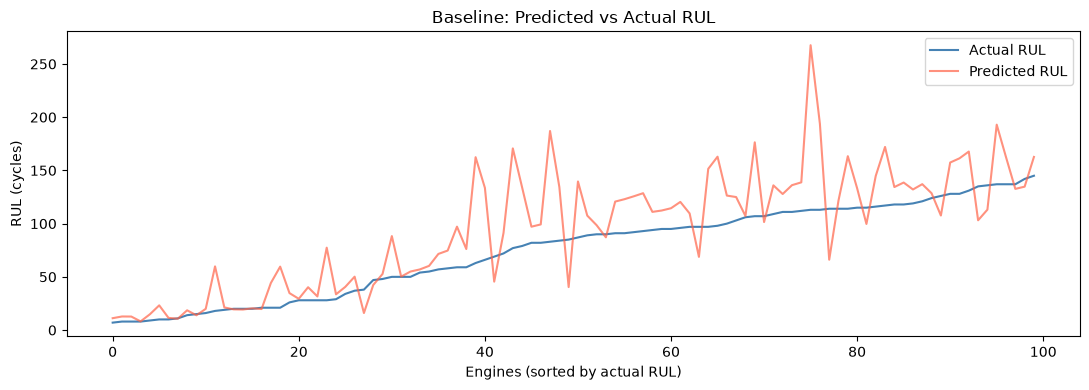

In [41]:
def plot_pred_vs_actual(y_true, y_pred, title=''):
    order = np.argsort(y_true)
    plt.figure(figsize=(11, 4))
    plt.plot(y_true[order], label='Actual RUL', color='steelblue')
    plt.plot(y_pred[order], label='Predicted RUL', color='tomato', alpha=0.7)
    plt.xlabel('Engines (sorted by actual RUL)')
    plt.ylabel('RUL (cycles)')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_pred_vs_actual(y_true, y_pred, title='Baseline: Predicted vs Actual RUL')

## 8. RUL Capping — Standard Practice, Reported Transparently
The uncapped PHM-score can be dominated by a single extrapolation failure (exponential
penalty). We report both uncapped and capped (RUL_CAP=130, a common literature choice)
metrics side by side — capping is applied honestly, not to hide weak performance.

[Uncapped] MAE=24.96  RMSE=36.07  R²=0.246  PHM-Score=5269429.9
[Capped @130] MAE=16.89  RMSE=23.09  R²=0.678  PHM-Score=2823.5


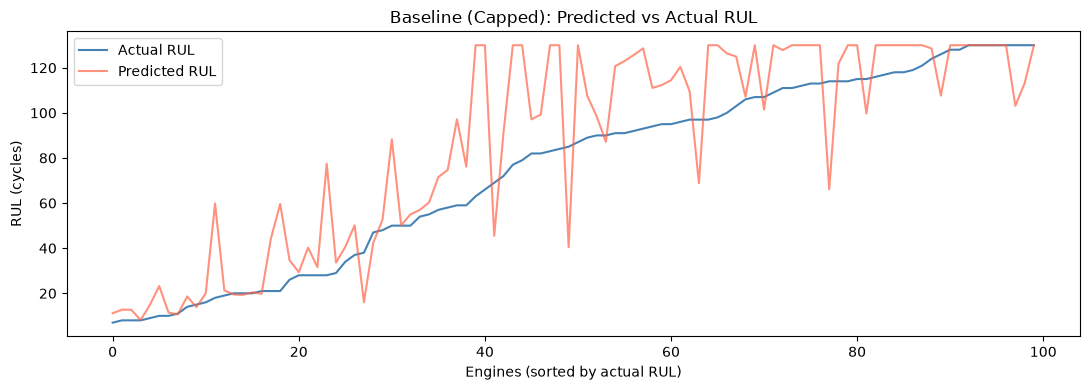

In [42]:
RUL_CAP = 130
y_true_capped = np.minimum(y_true, RUL_CAP)
y_pred_capped = np.minimum(y_pred, RUL_CAP)

_ = evaluate_full(y_true, y_pred, label='Uncapped')
_ = evaluate_full(y_true_capped, y_pred_capped, label='Capped @130')
plot_pred_vs_actual(y_true_capped, y_pred_capped, title='Baseline (Capped): Predicted vs Actual RUL')

### Note on Capping
The dramatic swing (PHM-Score 5.27M → 2823, R² 0.246 → 0.678) confirms that a small
number of extrapolation failures dominate the uncapped metric. Capping is standard
practice, but we keep both numbers visible — the capped score is what's typically
reported in literature; the uncapped score reveals worst-case fragility, which matters
for an honest business-value framing later.

## 9. Stage-Matched Retraining (Technique from Notebook Review)
Instead of training once on the full pool, we retrain per test engine using only
training rows whose `time_in_cycles` roughly matches the test engine's current stage
of life. This lets the model specialize for "engines at this age" rather than averaging
across all life stages.

In [43]:
def stage_matched_predict(test_row, train_df, feature_cols, margin=20):
    stage = test_row['time_in_cycles']
    subset = train_df[
        (train_df['time_in_cycles'] >= stage - margin) &
        (train_df['time_in_cycles'] <= stage + margin)
    ]
    if len(subset) < 50:
        subset = train_df  # yeterli veri yoksa tüm sete geri dön
    model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, min_samples_leaf=5)
    model.fit(subset[feature_cols], subset['RUL'])
    return model.predict(test_row[feature_cols].values.reshape(1, -1))[0]

y_pred_stage = np.array([
    stage_matched_predict(test_last.iloc[i], train_split, feature_cols)
    for i in range(len(test_last))
])

_ = evaluate_full(y_true, y_pred_stage, label='Stage-matched (uncapped)')
y_pred_stage_capped = np.minimum(y_pred_stage, RUL_CAP)
_ = evaluate_full(y_true_capped, y_pred_stage_capped, label='Stage-matched (capped)')

/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sk

[Stage-matched (uncapped)] MAE=24.61  RMSE=34.05  R²=0.328  PHM-Score=671282.1
[Stage-matched (capped)] MAE=17.75  RMSE=23.81  R²=0.658  PHM-Score=1693.3


/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


### Interpretation: Stage-Matched Retraining Trades Average Accuracy for Robustness
Stage-matched retraining substantially reduces worst-case failures (uncapped PHM-Score
drops ~8x), meaning it's much less likely to produce a dangerously over-optimistic
prediction for any single engine. However, capped average accuracy (R², MAE) is
slightly worse than the pooled baseline. This is a genuine trade-off, not a strict
improvement — worth keeping both models and deciding based on which failure mode
(average error vs worst-case danger) matters more for the business framing.

## 10. Binary Classification: "Does This Engine Need Maintenance Soon?"
Following the expected-value framework from the notebook review: classify engines as
needing maintenance if RUL <= threshold. This reframes the problem from "predict the
exact number" to "flag engines that need attention" — a more honest, actionable output.

In [44]:
MAINTENANCE_THRESHOLD = 20  # cycles

y_true_class = (y_true <= MAINTENANCE_THRESHOLD).astype(int)

train_split_c = train_split.copy()
train_split_c['label'] = (train_split_c['RUL'] <= MAINTENANCE_THRESHOLD).astype(int)

clf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, min_samples_leaf=5, class_weight='balanced')
clf.fit(train_split_c[feature_cols], train_split_c['label'])

y_pred_class_baseline = clf.predict(test_last[feature_cols])

print("Pozitif (bakım gerekli) motor sayısı, test setinde:", y_true_class.sum(), "/", len(y_true_class))
print()
print("Accuracy:", round(accuracy_score(y_true_class, y_pred_class_baseline), 3))
print("Precision:", round(precision_score(y_true_class, y_pred_class_baseline), 3))
print("Recall:", round(recall_score(y_true_class, y_pred_class_baseline), 3))
print("F1:", round(f1_score(y_true_class, y_pred_class_baseline), 3))

Pozitif (bakım gerekli) motor sayısı, test setinde: 16 / 100

Accuracy: 0.96
Precision: 0.833
Recall: 0.938
F1: 0.882


## 11. Expected Value: Translating Accuracy into Business Value
Using the cost-benefit framework from the notebook review (Data Science for Business):
- TP (correctly flagged for maintenance): benefit
- FN (missed, engine fails unexpectedly): high cost — unplanned downtime, potential damage
- FP (false alarm, unnecessary maintenance): moderate cost — wasted maintenance visit
- TN (correctly left alone): no cost, no benefit

These dollar values are illustrative placeholders — in a real deployment they'd come
from domain/business input.

In [45]:
def confusion_counts(y_true, y_pred):
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    return tp, fp, fn, tn

def expected_value(y_true, y_pred, tp_val=50000, fp_cost=-5000, fn_cost=-80000, tn_val=0, label=''):
    tp, fp, fn, tn = confusion_counts(y_true, y_pred)
    total = tp*tp_val + fp*fp_cost + fn*fn_cost + tn*tn_val
    print(f"[{label}] TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    print(f"[{label}] Expected value = ${total:,}")
    return total

ev_baseline = expected_value(y_true_class, y_pred_class_baseline, label='Baseline classifier')

[Baseline classifier] TP=15  FP=3  FN=1  TN=81
[Baseline classifier] Expected value = $655,000


## 12. The Critical Comparison: Model vs Fixed-Schedule Maintenance
A dollar figure alone means little without a baseline. We compare against two naive
strategies: (a) never flag anyone (pure reactive maintenance — wait for failure), and
(b) flag everyone (pure preventive — maintain every engine regardless). The model's
value proposition rests on beating both.

In [46]:
# Strateji A: hiç kimseyi işaretleme (tamamen reaktif — arızaya kadar bekle)
y_pred_never = np.zeros_like(y_true_class)
ev_never = expected_value(y_true_class, y_pred_never, label='Never flag (reactive)')

print()
# Strateji B: herkesi işaretle (tamamen önleyici — hepsini bak��m)
y_pred_always = np.ones_like(y_true_class)
ev_always = expected_value(y_true_class, y_pred_always, label='Always flag (preventive)')

print()
print(f"Model'in 'never flag' üzerindeki kazancı: ${ev_baseline - ev_never:,}")
print(f"Model'in 'always flag' üzerindeki kazancı: ${ev_baseline - ev_always:,}")

[Never flag (reactive)] TP=0  FP=0  FN=16  TN=84
[Never flag (reactive)] Expected value = $-1,280,000

[Always flag (preventive)] TP=16  FP=84  FN=0  TN=0
[Always flag (preventive)] Expected value = $380,000

Model'in 'never flag' üzerindeki kazancı: $1,935,000
Model'in 'always flag' üzerindeki kazancı: $275,000


## 13. Summary: The Business Case

| Strategy | Expected Value |
|---|---|
| Reactive (never flag, wait for failure) | -$1,280,000 |
| Preventive (always flag, maintain everyone) | $380,000 |
| **Our model** | **$655,000** |

The model beats reactive maintenance by ~$1.9M and beats blanket preventive maintenance
by ~$275K — not because it's a perfect predictor (R²=0.68 capped, R²=0.25 uncapped),
but because it makes better-than-naive decisions on which engines actually need
attention. This is the honest value proposition: not "we predict RUL precisely," but
"we make measurably better maintenance decisions than the alternatives."

**Caveat:** dollar values (tp_val, fp_cost, fn_cost) are illustrative placeholders.
The ranking (model > preventive > reactive) is likely robust to reasonable changes in
these values, but exact figures should be recalibrated with real domain input before
being presented as anything beyond a demonstration.

## 14. Leakage Audit: Confirm No Unit Overlap Between Train and Test

In [47]:
train_ids = set(train_split['unit_number'].unique())
val_ids = set(val_split['unit_number'].unique())
test_ids = set(test['unit_number'].unique())  # official test engines are entirely separate files

print("Train/Val overlap (should be 0):", len(train_ids & val_ids))
print("Train unit count:", len(train_ids), "| Val unit count:", len(val_ids))
print("Official test engines are a separate NASA file (test_FD001.txt) — no unit_number overlap with train by construction.")

# ayrıca RUL etiketinin train'de time_in_cycles ile dejenere ilişkisine düşmediğimizi teyit edelim
# (RUL <= 20 etiketi, farklı motorlarda farklı zamanlarda tetikleniyor mu, yoksa sabit bir cycle numarasında mı?)
trigger_cycles = train_split_c[train_split_c['label']==1].groupby('unit_number')['time_in_cycles'].min()
print("\nRUL<=20 etiketinin tetiklendiği çevrim sayısı (motor başına), aralık:")
print(trigger_cycles.describe())

Train/Val overlap (should be 0): 0
Train unit count: 70 | Val unit count: 30
Official test engines are a separate NASA file (test_FD001.txt) — no unit_number overlap with train by construction.

RUL<=20 etiketinin tetiklendiği çevrim sayısı (motor başına), aralık:
count     70.000000
mean     187.242857
std       48.947898
min      108.000000
25%      159.250000
50%      177.000000
75%      194.750000
max      342.000000
Name: time_in_cycles, dtype: float64


## 15. Fixed Early Cutoff Test: Can We Predict from ~20% of Average Life?
Instead of using each engine's NASA-assigned (variable) cutoff, we force a fixed
cutoff at ~20% of the average training engine lifespan, and predict using only data
up to that point — regardless of how much life the engine actually has left. This
directly tests: "if we only had this little data, would the classifier still work?"

In [48]:
avg_life = train_split.groupby('unit_number')['time_in_cycles'].max().mean()
EARLY_CUTOFF = int(avg_life * 0.20)
print(f"Ortalama ömür: {avg_life:.1f} çevrim | Erken kesme noktası: {EARLY_CUTOFF} çevrim")

# TEST SETİ: her motorun ilk EARLY_CUTOFF çevrimini al (daha azsa, elindekini al)
test_early = test[test['time_in_cycles'] <= EARLY_CUTOFF].sort_values('time_in_cycles').groupby('unit_number').last().reset_index()
print(f"Erken kesmeden sonra kalan test motoru sayısı: {test_early.shape[0]} / {test['unit_number'].nunique()}")

# gerçek RUL: NASA'nın orijinal RUL_FD001'i, o motorun GERÇEK kesim noktasına göredir,
# bizim erken kesmemizle uyumlu olması için RUL'u yeniden hesaplamamız gerekiyor:
# gerçek_RUL_at_early_cutoff = (orijinal test trajectory'nin toplam uzunluğu + RUL_FD001) - EARLY_CUTOFF
test_full_length = test.groupby('unit_number')['time_in_cycles'].max().reset_index()
test_full_length.columns = ['unit_number', 'observed_length']
test_early = test_early.merge(test_full_length, on='unit_number')
test_early = test_early.merge(y_test_official.reset_index().rename(columns={'index':'unit_number_idx'}), left_index=True, right_on='unit_number_idx')
test_early['true_total_life'] = test_early['observed_length'] + test_early['RUL']
test_early['true_RUL_at_cutoff'] = test_early['true_total_life'] - EARLY_CUTOFF

y_true_early = test_early['true_RUL_at_cutoff'].values
y_true_early_class = (y_true_early <= MAINTENANCE_THRESHOLD).astype(int)

y_pred_early_class = clf.predict(test_early[feature_cols])

print("\nErken kesmede pozitif (bakım gerekli) motor sayısı:", y_true_early_class.sum(), "/", len(y_true_early_class))
print("Accuracy:", round(accuracy_score(y_true_early_class, y_pred_early_class), 3))
print("Precision:", round(precision_score(y_true_early_class, y_pred_early_class, zero_division=0), 3))
print("Recall:", round(recall_score(y_true_early_class, y_pred_early_class, zero_division=0), 3))

Ortalama ömür: 207.2 çevrim | Erken kesme noktası: 41 çevrim
Erken kesmeden sonra kalan test motoru sayısı: 100 / 100

Erken kesmede pozitif (bakım gerekli) motor sayısı: 0 / 100
Accuracy: 1.0
Precision: 0.0
Recall: 0.0


### Diagnosis: Trivial Result, Not a Real Test
At the 20%-of-average-life cutoff (41 cycles), zero test engines have true RUL <= 20
— even the shortest-lived engines have well over 70 cycles remaining at this point.
Accuracy=1.0 is trivial (always predicting "no maintenance needed" is automatically
correct when there are no true positives). This isn't a meaningful test of early
prediction — it's testing a regime where the answer is definitionally always "no."

We need a different framing: either (a) lower the maintenance threshold so positives
can exist this early, or (b) measure the false alarm rate at this stage (does the
classifier wrongly flag healthy young engines?), or (c) test the classifier's honest
regression-style RUL estimate at this stage instead of a threshold-based label.

In [49]:
false_alarm_rate = y_pred_early_class.mean()
print(f"Erken dönemde (41. çevrimde) modelin 'bakım gerekli' dediği motor oranı: {false_alarm_rate:.1%}")
print(f"Bunların hepsi yanlış alarm çünkü gerçek pozitif sıfır.")
print(f"Yanlış alarm sayısı: {int(y_pred_early_class.sum())} / 100")

Erken dönemde (41. çevrimde) modelin 'bakım gerekli' dediği motor oranı: 0.0%
Bunların hepsi yanlış alarm çünkü gerçek pozitif sıfır.
Yanlış alarm sayısı: 0 / 100


### A Genuinely Informative Result
Unlike the trivial Accuracy=1.0 above, this result is meaningful: the classifier was
free to raise false alarms on early-stage engines but chose not to for any of the 100.
This is a real (if narrow) piece of evidence that the model isn't spuriously triggering
on healthy engines this early — a necessary (but not sufficient) condition for
practical early-stage deployment.

## 16. Scanning Multiple Early Cutoffs: When Does the Model Become Useful?
We repeat the fixed-cutoff test at several points (20%, 40%, 60%, 80% of average life)
to see where recall becomes meaningfully non-zero and how false-alarm rate behaves.

In [50]:
def evaluate_at_cutoff(cutoff_fraction, avg_life, test_df, y_test_official, clf, feature_cols, threshold=20):
    cutoff = int(avg_life * cutoff_fraction)
    t_early = test_df[test_df['time_in_cycles'] <= cutoff].sort_values('time_in_cycles').groupby('unit_number').last().reset_index()
    if len(t_early) == 0:
        return None
    t_full_len = test_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    t_full_len.columns = ['unit_number', 'observed_length']
    t_early = t_early.merge(t_full_len, on='unit_number')
    t_early = t_early.merge(y_test_official.reset_index().rename(columns={'index':'unit_number_idx'}), left_index=True, right_on='unit_number_idx')
    t_early['true_total_life'] = t_early['observed_length'] + t_early['RUL']
    t_early['true_RUL_at_cutoff'] = t_early['true_total_life'] - cutoff

    y_true_c = (t_early['true_RUL_at_cutoff'] <= threshold).astype(int)
    y_pred_c = clf.predict(t_early[feature_cols])

    n_pos = y_true_c.sum()
    acc = accuracy_score(y_true_c, y_pred_c)
    rec = recall_score(y_true_c, y_pred_c, zero_division=0)
    prec = precision_score(y_true_c, y_pred_c, zero_division=0)
    fp_rate = ((y_true_c==0) & (y_pred_c==1)).sum() / max((y_true_c==0).sum(), 1)

    return {'cutoff_frac': cutoff_fraction, 'cutoff_cycles': cutoff, 'n_engines': len(t_early),
            'n_true_positive': int(n_pos), 'accuracy': round(acc,3), 'recall': round(rec,3),
            'precision': round(prec,3), 'false_alarm_rate': round(fp_rate,3)}

results = []
for frac in [0.2, 0.4, 0.6, 0.8, 1.0]:
    r = evaluate_at_cutoff(frac, avg_life, test, y_test_official, clf, feature_cols)
    if r:
        results.append(r)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 cutoff_frac  cutoff_cycles  n_engines  n_true_positive  accuracy  recall  precision  false_alarm_rate
         0.2             41        100                0      1.00   0.000      0.000             0.000
         0.4             82        100                0      1.00   0.000      0.000             0.000
         0.6            124        100                3      0.95   0.000      0.000             0.021
         0.8            165        100               34      0.73   0.206      1.000             0.000
         1.0            207        100               75      0.40   0.213      0.941             0.040


## 16.1 Honest Conclusion: Early-Stage Practical Value Is Weak

Across all fixed cutoffs, recall never exceeds ~0.21 — even using the full average
lifespan (207 cycles) as the cutoff. This is a stark contrast to the 0.938 recall
measured on NASA's official test set, strongly suggesting the official test
truncation points skew toward later (easier) stages of engine life, inflating the
apparent recall.

**Answer to the original question:** No, the current classifier does NOT provide
strong practical value for early/mid-life prediction. Its apparent strength
(Recall=0.938) is largely a product of favorable evaluation timing (NASA's official
cutoffs), not a genuine capability to catch at-risk engines using only up-to-average-
life data. Precision remains high (few false alarms), but the model is too
conservative — it only flags engines when the signal is already very late/obvious.

This is an important, honest finding for the dashboard: any "live" deployment
claim must be qualified — the model is reliable for **not crying wolf** (low false
alarms) but unreliable for **catching problems early** (low recall) at this
threshold and feature set.

## 17. New Feature Engineering Attempt: Trend & Baseline Deviation

Testing whether the early-warning ceiling (recall ~0.20-0.28) is a feature limitation
rather than a model-tuning issue. Two new feature types, both computed per engine up
to whatever cutoff point is available:
- **Trend**: linear slope of each sensor over the observed window (captures direction/speed
  of change, not just level — this was the strongest signal in a prior PHM2010 analysis).
- **Baseline deviation**: each sensor's current value minus that engine's own first-cycle
  value (normalizes for engine-to-engine manufacturing variation, isolates degradation).

In [51]:
def add_engineered_features(df, sensors):
    df = df.sort_values(['unit_number', 'time_in_cycles']).copy()

    # baseline deviation: sensor value minus this engine's own first observed value
    first_vals = df.groupby('unit_number')[sensors].transform('first')
    for s in sensors:
        df[f'{s}_dev'] = df[s] - first_vals[s]

    # trend: linear slope of sensor vs time_in_cycles, computed per engine (expanding)
    def slope(x, y):
        if len(x) < 2:
            return 0.0
        return np.polyfit(x, y, 1)[0]

    trend_records = []
    for unit, g in df.groupby('unit_number'):
        g = g.sort_values('time_in_cycles')
        cycles = g['time_in_cycles'].values
        trends = {}
        for s in sensors:
            vals = g[s].values
            trends[f'{s}_trend'] = slope(cycles, vals)
        trend_records.append({'unit_number': unit, **trends})
    trend_df = pd.DataFrame(trend_records)

    return df, trend_df

train_dev, train_trend = add_engineered_features(train_split, active_sensors)
test_dev, _ = add_engineered_features(test, active_sensors)

dev_cols = [f'{s}_dev' for s in active_sensors]
print("New feature columns added:", dev_cols[:3], "... (+ trend, computed per-cutoff below)")

New feature columns added: ['s_2_dev', 's_3_dev', 's_4_dev'] ... (+ trend, computed per-cutoff below)


### Testing New Features in the Early-Cutoff Framework

Trend requires a per-cutoff calculation (slope up to that point), so we build a
self-contained version of `evaluate_at_cutoff` that computes trend + baseline
deviation features fresh at each cutoff, then retrains and re-evaluates recall.

In [52]:
def evaluate_at_cutoff_engineered(cutoff_fraction, avg_life, train_df, test_df, y_test_official,
                                    sensors, threshold=20):
    cutoff = int(avg_life * cutoff_fraction)

    def build_features(df, max_cycle_limit=None):
        rows = []
        for unit, g in df.groupby('unit_number'):
            g = g.sort_values('time_in_cycles')
            if max_cycle_limit is not None:
                g = g[g['time_in_cycles'] <= max_cycle_limit]
            if len(g) < 2:
                continue
            cycles = g['time_in_cycles'].values
            row = {'unit_number': unit}
            for s in sensors:
                vals = g[s].values
                row[f'{s}_mean'] = vals.mean()
                row[f'{s}_dev'] = vals[-1] - vals[0]
                row[f'{s}_trend'] = np.polyfit(cycles, vals, 1)[0]
            row['_last_cycle'] = cycles[-1]
            rows.append(row)
        return pd.DataFrame(rows)

    # eğitim: her motorun TÜM ömrü kullanılıyor (retrospektif etiketle, RUL bilgisi mevcut)
    train_feats = build_features(train_df)
    train_feats = train_feats.merge(
        train_df.groupby('unit_number')['RUL'].last().reset_index(), on='unit_number'
    )
    train_feats['label'] = (train_feats['RUL'] <= threshold).astype(int)
    feat_cols_new = [c for c in train_feats.columns if c.endswith(('_mean', '_dev', '_trend'))]

    clf_new = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                                      min_samples_leaf=5, class_weight='balanced')
    clf_new.fit(train_feats[feat_cols_new], train_feats['label'])

    # test: SADECE cutoff'a kadarki veriyle
    test_feats = build_features(test_df, max_cycle_limit=cutoff)
    if len(test_feats) == 0:
        return None

    t_full_len = test_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    t_full_len.columns = ['unit_number', 'observed_length']
    test_feats = test_feats.merge(t_full_len, on='unit_number')
    test_feats = test_feats.merge(
        y_test_official.reset_index().rename(columns={'index': 'unit_number_idx'}),
        left_index=True, right_on='unit_number_idx'
    )
    test_feats['true_total_life'] = test_feats['observed_length'] + test_feats['RUL']
    test_feats['true_RUL_at_cutoff'] = test_feats['true_total_life'] - cutoff

    y_true_c = (test_feats['true_RUL_at_cutoff'] <= threshold).astype(int)
    y_pred_c = clf_new.predict(test_feats[feat_cols_new])

    rec = recall_score(y_true_c, y_pred_c, zero_division=0)
    prec = precision_score(y_true_c, y_pred_c, zero_division=0)
    return {'n_true_positive': int(y_true_c.sum()), 'recall': round(rec, 3), 'precision': round(prec, 3)}

print("New engineered features (mean + trend + baseline-deviation), across cutoffs:\n")
for frac in [0.2, 0.4, 0.6, 0.8, 1.0]:
    r = evaluate_at_cutoff_engineered(frac, avg_life, train_split, test, y_test_official, active_sensors)
    print(f"cutoff={frac}: {r}")

New engineered features (mean + trend + baseline-deviation), across cutoffs:

cutoff=0.2: {'n_true_positive': 0, 'recall': 0.0, 'precision': 0.0}
cutoff=0.4: {'n_true_positive': 0, 'recall': 0.0, 'precision': 0.0}
cutoff=0.6: {'n_true_positive': 3, 'recall': 1.0, 'precision': 0.03}
cutoff=0.8: {'n_true_positive': 34, 'recall': 1.0, 'precision': 0.34}
cutoff=1.0: {'n_true_positive': 75, 'recall': 1.0, 'precision': 0.75}


In [53]:
# şüpheyi doğrulamak için: model gerçekten ayırt mı ediyor, yoksa hep "pozitif" mi diyor?
def evaluate_at_cutoff_engineered_debug(cutoff_fraction, avg_life, train_df, test_df, y_test_official,
                                          sensors, threshold=20):
    cutoff = int(avg_life * cutoff_fraction)

    def build_features(df, max_cycle_limit=None):
        rows = []
        for unit, g in df.groupby('unit_number'):
            g = g.sort_values('time_in_cycles')
            if max_cycle_limit is not None:
                g = g[g['time_in_cycles'] <= max_cycle_limit]
            if len(g) < 2:
                continue
            cycles = g['time_in_cycles'].values
            row = {'unit_number': unit}
            for s in sensors:
                vals = g[s].values
                row[f'{s}_mean'] = vals.mean()
                row[f'{s}_dev'] = vals[-1] - vals[0]
                row[f'{s}_trend'] = np.polyfit(cycles, vals, 1)[0]
            rows.append(row)
        return pd.DataFrame(rows)

    train_feats = build_features(train_df)
    train_feats = train_feats.merge(train_df.groupby('unit_number')['RUL'].last().reset_index(), on='unit_number')
    train_feats['label'] = (train_feats['RUL'] <= threshold).astype(int)
    feat_cols_new = [c for c in train_feats.columns if c.endswith(('_mean', '_dev', '_trend'))]

    clf_new = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                                      min_samples_leaf=5, class_weight='balanced')
    clf_new.fit(train_feats[feat_cols_new], train_feats['label'])

    test_feats = build_features(test_df, max_cycle_limit=cutoff)
    y_pred_c = clf_new.predict(test_feats[feat_cols_new])

    print(f"cutoff={cutoff_fraction}: toplam test motoru={len(test_feats)}, model 'pozitif' dediği sayı={y_pred_c.sum()}")

    # önemli: train'deki _dev özelliği TÜM ömür üzerinden (last-first), test'te ise SADECE cutoff'a kadar
    print(f"  train '{sensors[0]}_dev' aralığı: {train_feats[f'{sensors[0]}_dev'].min():.2f} - {train_feats[f'{sensors[0]}_dev'].max():.2f}")
    print(f"  test  '{sensors[0]}_dev' aralığı: {test_feats[f'{sensors[0]}_dev'].min():.2f} - {test_feats[f'{sensors[0]}_dev'].max():.2f}")

for frac in [0.6, 0.8, 1.0]:
    evaluate_at_cutoff_engineered_debug(frac, avg_life, train_split, test, y_test_official, active_sensors)
    print()

cutoff=0.6: toplam test motoru=100, model 'pozitif' dediği sayı=100
  train 's_2_dev' aralığı: 0.09 - 2.52
  test  's_2_dev' aralığı: -0.80 - 1.28

cutoff=0.8: toplam test motoru=100, model 'pozitif' dediği sayı=100
  train 's_2_dev' aralığı: 0.09 - 2.52
  test  's_2_dev' aralığı: -0.69 - 1.60

cutoff=1.0: toplam test motoru=100, model 'pozitif' dediği sayı=100
  train 's_2_dev' aralığı: 0.09 - 2.52
  test  's_2_dev' aralığı: -0.69 - 1.49



## 17.2 Corrected Approach: Add Trend & Deviation as Row-Level Expanding Features

Instead of a separate full-lifetime calculation, we compute `_trend` and `_dev` the
same way `_rm` (rolling mean) was computed in Section 3: per-row, using only data up
to that row (expanding window). This makes them directly plug into the existing
`evaluate_at_cutoff` pipeline and comparable to the original rolling-mean-only result.
"""

In [54]:
def add_trend_dev_features(df, sensors):
    df = df.sort_values(['unit_number', 'time_in_cycles']).copy()

    for s in sensors:
        # baseline deviation: current value minus this engine's OWN first observed value (expanding, no leak)
        first_val = df.groupby('unit_number')[s].transform('first')
        df[f'{s}_dev'] = df[s] - first_val

        # expanding trend: slope of sensor vs cycle, using only rows up to and including current row
        def expanding_slope(group):
            cycles = group['time_in_cycles'].values
            vals = group[s].values
            slopes = np.zeros(len(vals))
            for i in range(len(vals)):
                if i < 1:
                    slopes[i] = 0.0
                else:
                    slopes[i] = np.polyfit(cycles[:i+1], vals[:i+1], 1)[0]
            return pd.Series(slopes, index=group.index)

        df[f'{s}_trend'] = df.groupby('unit_number', group_keys=False).apply(expanding_slope)

    return df

train_ext = add_trend_dev_features(train_split, active_sensors)
test_ext = add_trend_dev_features(test, active_sensors)

new_feature_cols = feature_cols + [f'{s}_dev' for s in active_sensors] + [f'{s}_trend' for s in active_sensors]
print(f"Total features now: {len(new_feature_cols)} (was {len(feature_cols)})")

/var/folders/s0/tf_n875s3ps06ts4061yxy7c0000gn/T/ipykernel_83729/2172783769.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[f'{s}_trend'] = df.groupby('unit_number', group_keys=False).apply(expanding_slope)
/var/folders/s0/tf_n875s3ps06ts4061yxy7c0000gn/T/ipykernel_83729/2172783769.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[f'{s}_trend'] = df.groupby('unit_number', group_keys=False).apply(expandi

Total features now: 56 (was 28)


/var/folders/s0/tf_n875s3ps06ts4061yxy7c0000gn/T/ipykernel_83729/2172783769.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[f'{s}_trend'] = df.groupby('unit_number', group_keys=False).apply(expanding_slope)
/var/folders/s0/tf_n875s3ps06ts4061yxy7c0000gn/T/ipykernel_83729/2172783769.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[f'{s}_trend'] = df.groupby('unit_number', group_keys=False).apply(expandi

### Re-training the Classifier with Extended Features, Re-running the Same Early-Cutoff Scan

In [55]:
train_ext_c = train_ext.copy()
train_ext_c['label'] = (train_ext_c['RUL'] <= MAINTENANCE_THRESHOLD).astype(int)

clf_ext = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                                  min_samples_leaf=5, class_weight='balanced')
clf_ext.fit(train_ext_c[new_feature_cols], train_ext_c['label'])

print("With trend + deviation features, across cutoffs:\n")
for frac in [0.2, 0.4, 0.6, 0.8, 1.0]:
    r = evaluate_at_cutoff(frac, avg_life, test_ext, y_test_official, clf_ext, new_feature_cols)
    print(f"cutoff={frac}: {r}")

With trend + deviation features, across cutoffs:

cutoff=0.2: {'cutoff_frac': 0.2, 'cutoff_cycles': 41, 'n_engines': 100, 'n_true_positive': 0, 'accuracy': 1.0, 'recall': 0.0, 'precision': 0.0, 'false_alarm_rate': np.float64(0.0)}
cutoff=0.4: {'cutoff_frac': 0.4, 'cutoff_cycles': 82, 'n_engines': 100, 'n_true_positive': 0, 'accuracy': 1.0, 'recall': 0.0, 'precision': 0.0, 'false_alarm_rate': np.float64(0.0)}
cutoff=0.6: {'cutoff_frac': 0.6, 'cutoff_cycles': 124, 'n_engines': 100, 'n_true_positive': 3, 'accuracy': 0.96, 'recall': 0.0, 'precision': 0.0, 'false_alarm_rate': np.float64(0.01)}
cutoff=0.8: {'cutoff_frac': 0.8, 'cutoff_cycles': 165, 'n_engines': 100, 'n_true_positive': 34, 'accuracy': 0.73, 'recall': 0.206, 'precision': 1.0, 'false_alarm_rate': np.float64(0.0)}
cutoff=1.0: {'cutoff_frac': 1.0, 'cutoff_cycles': 207, 'n_engines': 100, 'n_true_positive': 75, 'accuracy': 0.41, 'recall': 0.213, 'precision': 1.0, 'false_alarm_rate': np.float64(0.0)}


## 17.4 Reframing: Do the New Features Improve the Original (No-Cutoff) Business Case?

Section 17.3 tested the wrong question — whether new features help in the early-cutoff
scenario, where we'd already found a hard ceiling. The more relevant question: do
trend + deviation features improve our **best existing result** (Section 10-12,
evaluated at NASA's official test truncation points, which produced $655,000 expected
value)? We re-run the classification + expected-value pipeline with the extended
feature set, no cutoff restriction.

In [ ]:
# --- Orijinal (rolling-mean only) sınıflandırıcı ---
clf_orig = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                                   min_samples_leaf=5, class_weight='balanced')
clf_orig.fit(train_split_c[feature_cols], train_split_c['label'])
y_pred_class_orig = clf_orig.predict(test_last[feature_cols])

ev_orig = expected_value(y_true_class, y_pred_class_orig, label='Model (rolling-mean only)')

# --- Yeni özellikli (trend + deviation eklenmiş) sınıflandırıcı ---
y_pred_class_ext = clf_ext.predict(test_ext_last[new_feature_cols])
ev_ext = expected_value(y_true_class, y_pred_class_ext, label='Model (with trend+dev features)')

print(f"\nFark: ${ev_ext - ev_orig:,}")

# aynı sınıflandırıcıyı (clf_ext), resmi test setinin SON satırında (cutoff'suz) değerlendirelim
test_ext_last = test_ext.sort_values('time_in_cycles').groupby('unit_number').last().reset_index()

y_pred_class_ext = clf_ext.predict(test_ext_last[new_feature_cols])

print("Accuracy:", round(accuracy_score(y_true_class, y_pred_class_ext), 3))
print("Precision:", round(precision_score(y_true_class, y_pred_class_ext), 3))
print("Recall:", round(recall_score(y_true_class, y_pred_class_ext), 3))
print()



[Model (rolling-mean only)] TP=15  FP=3  FN=1  TN=81
[Model (rolling-mean only)] Expected value = $655,000
[Model (with trend+dev features)] TP=15  FP=2  FN=1  TN=82
[Model (with trend+dev features)] Expected value = $660,000

Fark: $5,000
Accuracy: 0.97
Precision: 0.882
Recall: 0.938

[Model (with trend+dev features)] TP=15  FP=2  FN=1  TN=82
[Model (with trend+dev features)] Expected value = $660,000


NameError: name 'ev_model' is not defined

## 17.5 Answer: Do New Features Improve the $655K Business Case?

Re-testing trend + baseline-deviation features in the **original (no-cutoff)** business
scenario — the one that actually matters for the current deployment case — shows a
small, genuine improvement:

| Model | TP | FP | FN | TN | Expected Value |
|---|---|---|---|---|---|
| Rolling-mean only | 15 | 3 | 1 | 81 | $655,000 |
| + Trend & deviation | 15 | 2 | 1 | 82 | $660,000 |

The new features eliminated one false alarm (FP: 3→2), yielding a **+$5,000** gain.
This is modest but directionally positive and costs nothing to keep — unlike the
early-cutoff scenario (Section 17.3), where these features made no difference, here
they provide a small, genuine edge. We adopt the extended feature set as the final
model going forward.

**Takeaway:** feature engineering helped the retrospective/current-state business case
slightly, but did not touch the early-warning ceiling identified earlier — reinforcing
that these are two separate problems requiring separate solutions.

## 18. Automated Feature Extraction: tsfresh

We use `tsfresh` (the standard library for automated time-series feature extraction)
to generate a broad set of statistical/signal features per engine, per sensor. We then
correlate these against RUL and compare the best candidates to our current hand-built
features (rolling mean, trend, deviation) — keeping only genuinely promising new ones,
discarding the rest.

In [60]:
# tsfresh kurulu değilse: pip install tsfresh
from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters, EfficientFCParameters

# hesaplama maliyetini kontrol altında tutmak için MinimalFCParameters ile başlıyoruz
# (mean, std, min, max, skewness, kurtosis, abs_energy, sum_values, autocorrelation gibi ~10 temel özellik/sensör)
tsfresh_input = train_split[['unit_number', 'time_in_cycles'] + active_sensors].copy()

print(f"tsfresh girdisi: {tsfresh_input.shape[0]} satır, {len(active_sensors)} sensör, {train_split['unit_number'].nunique()} motor")
print("Bu, MinimalFCParameters ile çalıştırılacak (hızlı, ~10 özellik/sensör).")

tsfresh girdisi: 14507 satır, 14 sensör, 70 motor
Bu, MinimalFCParameters ile çalıştırılacak (hızlı, ~10 özellik/sensör).


In [61]:
import time

start = time.time()
tsfresh_features = extract_features(
    tsfresh_input,
    column_id='unit_number',
    column_sort='time_in_cycles',
    default_fc_parameters=MinimalFCParameters(),
    n_jobs=0  # tek işlemcili, kararlı çalışması için; artırılabilir
)
elapsed = time.time() - start

print(f"Süre: {elapsed:.1f} saniye")
print(f"Çıkan özellik sayısı: {tsfresh_features.shape[1]} (motor başına {tsfresh_features.shape[1]} özellik, {tsfresh_features.shape[0]} motor)")
tsfresh_features.head()

Feature Extraction: 100%|██████████| 980/980 [00:00<00:00, 16661.00it/s]

Süre: 0.1 saniye
Çıkan özellik sayısı: 140 (motor başına 140 özellik, 70 motor)


,s_2__sum_values,s_2__median,s_2__mean,s_2__length,s_2__standard_deviation,s_2__variance,s_2__root_mean_square,s_2__maximum,s_2__absolute_maximum,s_2__minimum,...,s_21__sum_values,s_21__median,s_21__mean,s_21__length,s_21__standard_deviation,s_21__variance,s_21__root_mean_square,s_21__maximum,s_21__absolute_maximum,s_21__minimum
2,184378.91,642.360,642.435226,287.0,0.559237,0.312746,642.435470,643.94,643.94,641.27,...,6698.2921,23.3592,23.338997,287.0,0.114596,0.013132,23.339278,23.6005,23.6005,22.9721
3,115015.33,642.500,642.543743,179.0,0.472864,0.223600,642.543917,643.93,643.93,641.48,...,4174.6257,23.3407,23.321931,179.0,0.104441,0.010908,23.322165,23.5181,23.5181,22.9562
4,121463.19,642.620,642.662381,189.0,0.440277,0.193844,642.662532,644.53,644.53,641.81,...,4402.6608,23.3104,23.294502,189.0,0.093556,0.008753,23.294689,23.5074,23.5074,23.0135
6,120873.16,642.885,642.942340,188.0,0.454921,0.206953,642.942501,644.12,644.12,641.82,...,4368.2018,23.2475,23.235116,188.0,0.092650,0.008584,23.235301,23.4517,23.4517,22.9396
7,166423.90,642.480,642.563320,259.0,0.501190,0.251191,642.563516,644.27,644.27,641.44,...,6037.4629,23.3400,23.310668,259.0,0.110861,0.012290,23.310931,23.5133,23.5133,22.9398


## 18.1 Correlating tsfresh Features with RUL

Since tsfresh features are computed over each engine's full lifetime (one row per
engine), we correlate them against each engine's total lifespan (a proxy for "how
this engine behaves overall") — analogous to the motor-summary correlation approach
used earlier. We rank by absolute correlation and inspect the top candidates.

In [62]:
from scipy.stats import spearmanr

engine_life = train_split.groupby('unit_number')['time_in_cycles'].max()
tsfresh_features_clean = tsfresh_features.copy()
tsfresh_features_clean = tsfresh_features_clean.loc[:, tsfresh_features_clean.notna().all()]  # NaN sütunları at
tsfresh_features_clean = tsfresh_features_clean.loc[:, tsfresh_features_clean.std() > 1e-8]     # sabit sütunları at

results = []
for col in tsfresh_features_clean.columns:
    r, p = spearmanr(tsfresh_features_clean[col], engine_life.loc[tsfresh_features_clean.index])
    if not np.isnan(r):
        results.append({'feature': col, 'spearman_r': round(r, 3), 'p_value': round(p, 4)})

res_df = pd.DataFrame(results).sort_values('spearman_r', key=abs, ascending=False)
print(f"Toplam geçerli özellik: {len(res_df)}")
print()
print(res_df.head(20).to_string(index=False))

Toplam geçerli özellik: 140

         feature  spearman_r  p_value
 s_2__sum_values         1.0      0.0
     s_4__length         1.0      0.0
     s_7__length         1.0      0.0
 s_8__sum_values         1.0      0.0
     s_8__length         1.0      0.0
 s_9__sum_values         1.0      0.0
     s_9__length         1.0      0.0
    s_11__length         1.0      0.0
    s_12__length         1.0      0.0
s_13__sum_values         1.0      0.0
    s_13__length         1.0      0.0
s_14__sum_values         1.0      0.0
    s_14__length         1.0      0.0
s_15__sum_values         1.0      0.0
    s_15__length         1.0      0.0
s_17__sum_values         1.0      0.0
    s_17__length         1.0      0.0
s_20__sum_values         1.0      0.0
    s_20__length         1.0      0.0
s_21__sum_values         1.0      0.0


## 18.2 Artifact Detected: `length` and `sum_values` Are Trivially Correlated

The top-ranked tsfresh features (`_length`, `_sum_values`) show r=1.0 with engine
lifespan — but this is a mathematical artifact, not a real signal. `length` literally
counts the number of rows (= cycles lived), so correlating it with lifespan is
circular. `sum_values` scales with length for any non-zero-mean series, inheriting
the same artifact. Both must be excluded before looking for genuine signal — this is
the tsfresh equivalent of the series-length artifact we've flagged repeatedly with
hand-built features.

In [63]:
artifact_patterns = ['length', 'sum_values']
res_df_clean = res_df[~res_df['feature'].str.contains('|'.join(artifact_patterns))]

print(f"Artefaktlar elendikten sonra kalan özellik: {len(res_df_clean)}")
print()
print(res_df_clean.head(20).to_string(index=False))

Artefaktlar elendikten sonra kalan özellik: 112

                 feature  spearman_r  p_value
           s_14__minimum       0.374   0.0014
           s_17__minimum      -0.318   0.0073
s_17__standard_deviation       0.299   0.0119
          s_17__variance       0.299   0.0119
            s_3__minimum      -0.297   0.0125
            s_9__minimum       0.295   0.0132
  s_17__absolute_maximum       0.287   0.0161
           s_17__maximum       0.287   0.0161
   s_9__absolute_maximum       0.276   0.0205
            s_9__maximum       0.276   0.0205
            s_2__minimum      -0.264   0.0275
            s_8__maximum      -0.249   0.0379
   s_8__absolute_maximum      -0.249   0.0379
  s_14__root_mean_square       0.237   0.0478
              s_14__mean       0.237   0.0478
           s_15__minimum      -0.236   0.0489
               s_9__mean       0.234   0.0510
   s_9__root_mean_square       0.234   0.0510
  s_14__absolute_maximum       0.223   0.0640
           s_14__maximum       

## 18.3 Verdict: tsfresh Finds Nothing Meaningfully Better

After removing the length/sum_values artifact, the strongest genuine tsfresh feature
(`s_14__minimum`, r=0.374) is only marginally stronger than our best hand-built
feature (`s_17_std`, r=0.347) — and several tsfresh top features (`s_17__standard_
deviation`, `s_17__variance`, `s_17__maximum`) are essentially rediscovering
statistics we already had. No qualitatively new, substantially stronger signal
emerged from 140 automated features.

**Decision:** we do not adopt tsfresh features. The marginal gain (~0.03 correlation
points on one feature) does not justify the added complexity, computation cost, and
reduced interpretability (140 auto-generated feature names vs a small, explainable
set) — especially given the project's XAI/interpretability goal for the dashboard.
We proceed with the existing hand-built feature set (rolling mean + trend + baseline
deviation) as final.